In [8]:
from collections import namedtuple
from typing import Tuple

import os
import subprocess
import pickle
import numpy as np
import matplotlib.pyplot as plt

#### Utilities

In [9]:
EdgeCounts = namedtuple("EdgeCounts", ["boyerMyrvold", "mst", "cactus"])
Ratios = namedtuple("Ratios", ["boyerMyrvold", "mst", "cactus"])
Times = namedtuple("Times", ["boyerMyrvold", "mst", "cactus"])

AverageResult = namedtuple(
    "AverageResult",
    ["basic", "weighted", "maximizedBasic", "maximizedWeighted"]
)

TestResult = namedtuple(
    "TestResult",
    ["edges", "ratios", "times"]
)

In [10]:
def test_maximal_planar_subgraph(n0: int, n: int, m: int, reps: int) -> Tuple[TestResult, TestResult] | None:
    try:
        result = subprocess.run(
            ["../build/maximal_planar_subgraphs", str(5), str(n0), str(m), str(n), str(reps)],
            check=True,
            capture_output=True,
            text=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        return None
    
    output_lines = result.stdout.strip().splitlines()
    if len(output_lines) < 3:
        print("Unexpected output format")
        return None

    edges_values = list(map(float, output_lines[0].split()))
    edges_mean = AverageResult(
        basic=EdgeCounts(edges_values[0], edges_values[8], edges_values[16]),
        weighted=EdgeCounts(edges_values[2], edges_values[10], edges_values[18]),
        maximizedBasic=EdgeCounts(edges_values[4], edges_values[12], edges_values[20]),
        maximizedWeighted=EdgeCounts(edges_values[6], edges_values[14], edges_values[22])
    )
    edges_std = AverageResult(
        basic=EdgeCounts(edges_values[1], edges_values[9], edges_values[17]),
        weighted=EdgeCounts(edges_values[3], edges_values[11], edges_values[19]),
        maximizedBasic=EdgeCounts(edges_values[5], edges_values[13], edges_values[21]),
        maximizedWeighted=EdgeCounts(edges_values[7], edges_values[15], edges_values[23])
    )

    ratio_values = list(map(float, output_lines[1].split()))
    ratios_mean = AverageResult(
        basic=Ratios(ratio_values[0], ratio_values[8], ratio_values[16]),
        weighted=Ratios(ratio_values[2], ratio_values[10], ratio_values[18]),
        maximizedBasic=Ratios(ratio_values[4], ratio_values[12], ratio_values[20]),
        maximizedWeighted=Ratios(ratio_values[6], ratio_values[14], ratio_values[22])
    )
    ratio_std = AverageResult(
        basic=Ratios(ratio_values[1], ratio_values[9], ratio_values[17]),
        weighted=Ratios(ratio_values[3], ratio_values[11], ratio_values[19]),
        maximizedBasic=Ratios(ratio_values[5], ratio_values[13], ratio_values[21]),
        maximizedWeighted=Ratios(ratio_values[7], ratio_values[15], ratio_values[23])
    )

    time_values = list(map(float, output_lines[2].split()))
    times_mean = AverageResult(
        basic=Times(time_values[0], time_values[8], time_values[16]),
        weighted=Times(time_values[2], time_values[10], time_values[18]),
        maximizedBasic=Times(time_values[4], time_values[12], time_values[20]),
        maximizedWeighted=Times(time_values[6], time_values[14], time_values[22])
    )
    time_std = AverageResult(
        basic=Times(time_values[1], time_values[9], time_values[17]),
        weighted=Times(time_values[3], time_values[11], time_values[19]),
        maximizedBasic=Times(time_values[5], time_values[13], time_values[21]),
        maximizedWeighted=Times(time_values[7], time_values[15], time_values[23])
    )

    return TestResult(edges_mean, ratios_mean, times_mean), TestResult(edges_std, ratio_std, time_std)

#### Maximal Planar Subgraph Selection

In [11]:
GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 1051, 50))
GRAPH_M_VALUES = list(range(2, 6, 1))

REPETITIONS = 100
ALWAYS_REWRITE = True

In [12]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/maximal_planar_subgraph_m{m}.pkl"
    
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    results = []
    for n in GRAPH_N_VALUES:
        result = test_maximal_planar_subgraph(GRAPH_N0, n, m, REPETITIONS)
        if not result:
            print("Experiment failed")
            exit(1)
        
        results.append(result)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, results), f)

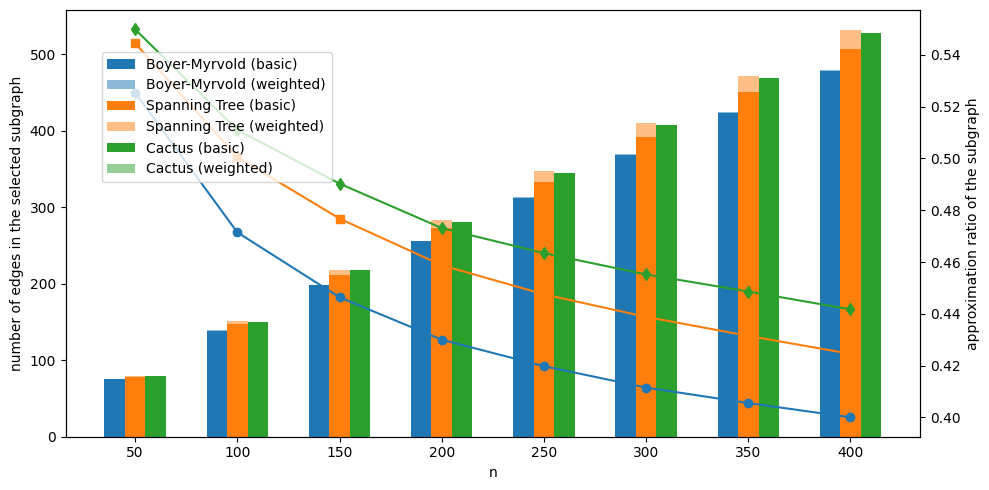

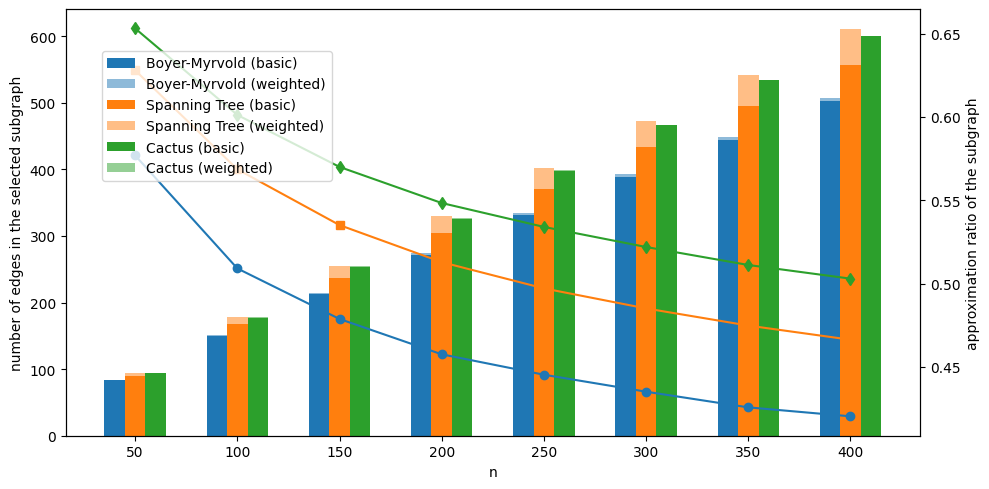

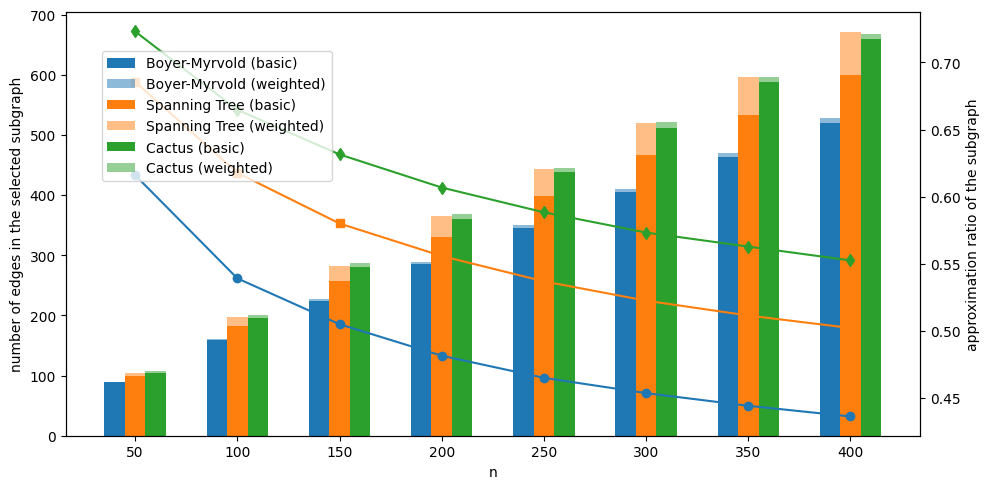

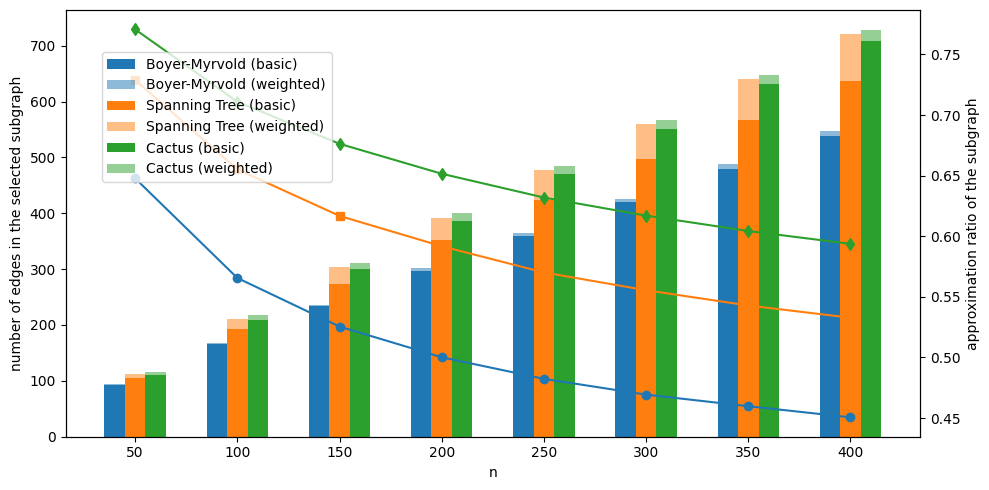

In [17]:
for m in GRAPH_M_VALUES:
    with open(f"cache/maximal_planar_subgraph_m{m}.pkl", "rb") as f:
        n_values, results = pickle.load(f)

        n_values = n_values

    results_mean = [r[0] for r in results]
    results_std  = [r[1] for r in results]

    basic_boyer_edges = [r.edges.maximizedBasic.boyerMyrvold for r in results_mean]
    basic_mst_edges   = [r.edges.maximizedBasic.mst for r in results_mean]
    basic_cactus_edges = [r.edges.maximizedBasic.cactus for r in results_mean]

    weighted_boyer_edges = [r.edges.maximizedWeighted.boyerMyrvold for r in results_mean]
    weighted_mst_edges   = [r.edges.maximizedWeighted.mst for r in results_mean]
    weighted_cactus_edges = [r.edges.maximizedWeighted.cactus for r in results_mean]

    diff_edges_boyer = [w - b for w, b in zip(weighted_boyer_edges, basic_boyer_edges)]
    diff_edges_mst   = [w - b for w, b in zip(weighted_mst_edges, basic_mst_edges)]
    diff_edges_cactus = [w - b for w, b in zip(weighted_cactus_edges, basic_cactus_edges)]

    basic_boyer_ratio = [r.ratios.maximizedBasic.boyerMyrvold for r in results_mean]
    basic_mst_ratio   = [r.ratios.maximizedBasic.mst for r in results_mean]
    basic_cactus_ratio = [r.ratios.maximizedBasic.cactus for r in results_mean]

    weighted_boyer_ratio = [r.ratios.maximizedWeighted.boyerMyrvold for r in results_mean]
    weighted_mst_ratio   = [r.ratios.maximizedWeighted.mst for r in results_mean]
    weighted_cactus_ratio = [r.ratios.maximizedWeighted.cactus for r in results_mean]

    x = np.arange(len(n_values))
    width = 0.2

    fig, ax1 = plt.subplots(figsize=(10,5))

    color_boyer  = "#1f77b4"
    color_mst    = "#ff7f0e"
    color_cactus = "#2ca02c"

    ax1.bar(x - width, basic_boyer_edges,  width, label="Boyer-Myrvold (basic)", color=color_boyer)
    ax1.bar(x - width, diff_edges_boyer, width,
            bottom=basic_boyer_edges, label="Boyer-Myrvold (weighted)", alpha=0.5, color=color_boyer)

    ax1.bar(x, basic_mst_edges, width, label="Spanning Tree (basic)", color=color_mst)
    ax1.bar(x, diff_edges_mst, width,
            bottom=basic_mst_edges, label="Spanning Tree (weighted)", alpha=0.5, color=color_mst)

    ax1.bar(x + width, basic_cactus_edges, width, label="Cactus (basic)", color=color_cactus)
    ax1.bar(x + width, diff_edges_cactus, width,
            bottom=basic_cactus_edges, label="Cactus (weighted)", alpha=0.5, color=color_cactus)


    ax1.set_xlabel("n")
    ax1.set_ylabel("number of edges in the selected subgraph")
    ax1.set_xticks(x)
    ax1.set_xticklabels(n_values)

    ax2 = ax1.twinx()
    ax2.plot(x, basic_boyer_ratio, marker="o")
    ax2.plot(x, basic_mst_ratio, marker="s")
    ax2.plot(x, basic_cactus_ratio, marker="d")
    ax2.set_ylabel("approximation ratio of the subgraph")

    fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

    fig.tight_layout()
    plt.show()